In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-employability-dataset/Student-Employability-Datasets.xlsx


### DATA PREPARATION ###

In [2]:
## Importing the files

df = pd.read_excel("/kaggle/input/students-employability-dataset/Student-Employability-Datasets.xlsx")
df.head(3)

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable


In [3]:
## Scanning the values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF-CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   Student Performance Rating  2982 non-null   int64 
 9   CLASS                       2982 non-null   object
dtypes: int64(8), object(2)
memory usage: 233.1+ KB


In [4]:
## Summarize the values

df.describe()

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating
count,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000
mean,4.246814,3.884641,3.972166,3.962777,3.910798,3.813883,3.525486,4.610664
std,0.678501,0.757013,0.744135,0.781982,0.807602,0.739390,0.743881,0.692845
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [5]:
## Renaming the columns

renamed_columns = {
    "Name of Student" : "name_student",
    "GENERAL APPEARANCE":"general_appearance",
    "MANNER OF SPEAKING" : "manner_of_speaking",
    "PHYSICAL CONDITION" : "physical_condition",
    "MENTAL ALERTNESS" : "mental_alertness",
    "SELF-CONFIDENCE" : "self_confidence",
    "ABILITY TO PRESENT IDEAS" : "ability_to_present_ideas",
    "COMMUNICATION SKILLS" : "comm_skills",
    "Student Performance Rating" : "student_performance",
    "CLASS" : "result"
}

df = df.rename(columns=renamed_columns)

### DATA ANALYSIS ###

In [6]:
## Adding an average column

df["average_score"] = df.mean(numeric_only=True, axis=1)
df.head(5)

,name_student,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,comm_skills,student_performance,result,average_score
0,Student 1,4,5,4,5,5,5,5,5,Employable,4.750
1,Student 2,4,4,4,4,4,4,3,5,Employable,4.000
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable,3.250
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable,3.125
4,Student 5,4,4,3,3,4,4,3,5,Employable,3.750


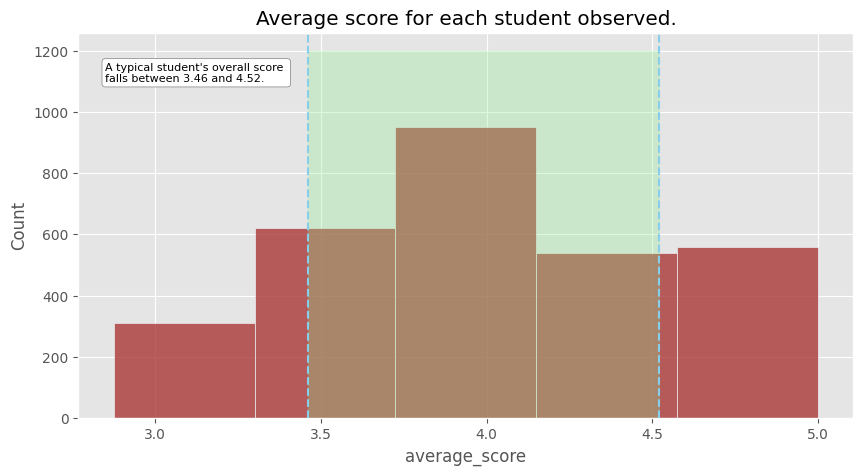

In [7]:
## Plotting the histogram or distribution of mean scores

## Creating the chart

plt.figure(figsize=(10,5))
sns.histplot(df["average_score"], bins=5,color="brown")

## Annotating the chart

## average score + std
df_mean = df["average_score"].mean()
df_std = df["average_score"].std()

## upper limit _ lower limit
df_upper = round(df_mean + df_std, 2)
df_lower = round(df_mean - df_std,2 )

## plotting the vertical lines
plt.axvline(df_upper, linestyle="--", color="skyblue", label=f'UPPER LIMIT: {df_upper}')
plt.axvline(df_lower, linestyle="--", color="skyblue", label=f'LOWERL IMIT: {df_lower}')
plt.fill_betweenx(
    y=[0, 1200],
    x1 = df_upper,
    x2 = df_lower,
    alpha=0.3,
    color="lightgreen"
)

plt.title("Average score for each student observed.")

plt.text(2.85, 1100,
    f"A typical student's overall score \nfalls between {df_lower} and {df_upper}.",
         fontsize=8,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.3"
    )
)

## Showing the chart
plt.show()

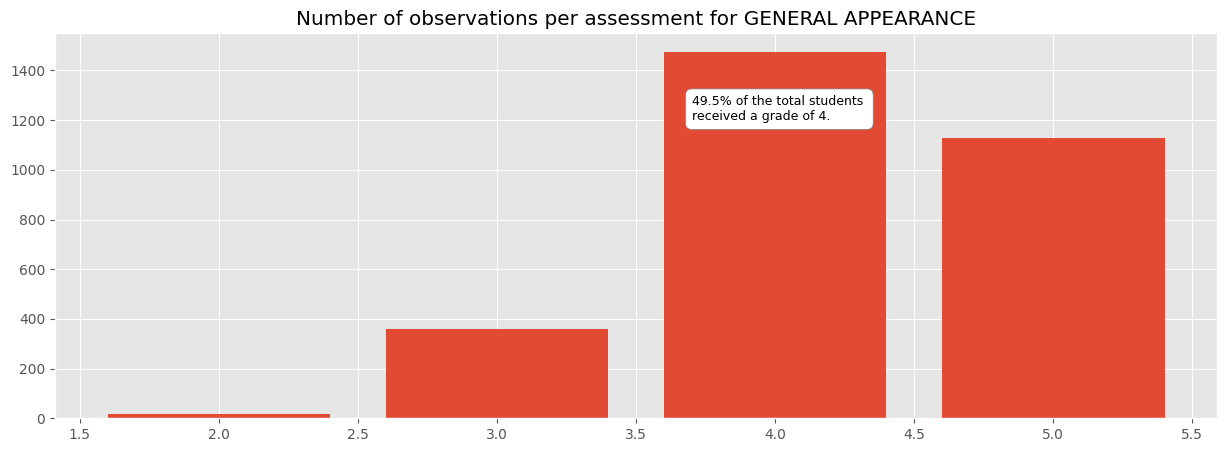

In [8]:
## What is the most common grading for GENERAL APPEARANCE?

viz_df = df.groupby("general_appearance")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["general_appearance"]
viz_df_y = viz_df["name_student"]

four_rate = round((len(df[df["general_appearance"] == 4]) / len(df)) * 100, 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for GENERAL APPEARANCE")

## Annotating the chart

plt.text(
    3.7, 1200,
    f'{four_rate}% of the total students \nreceived a grade of 4.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)

## Showing the graph

plt.show()

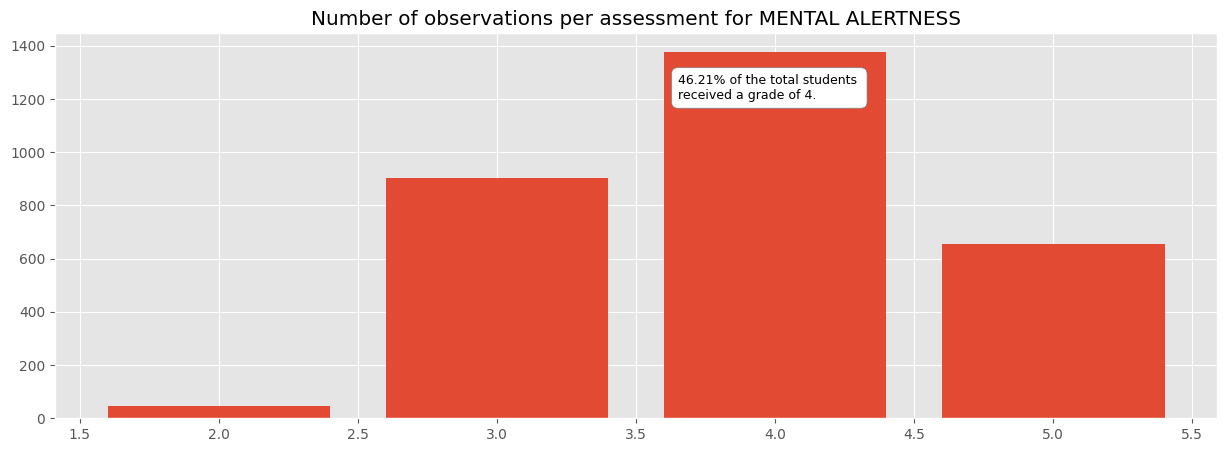

In [9]:
## What is the most common grading for MANNER OF SPEAKING?

viz_df = df.groupby("manner_of_speaking")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["manner_of_speaking"]
viz_df_y = viz_df["name_student"]

## Finding the proportion of students who received a grade of 4.0

four_rate = round((len(df[df["manner_of_speaking"] == 4]) / len(df)) * 100, 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for MENTAL ALERTNESS")

## Annotating the chart

plt.text(
    3.65, 1200,
    f'{four_rate}% of the total students \nreceived a grade of 4.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)


## Showing the graph

plt.show()

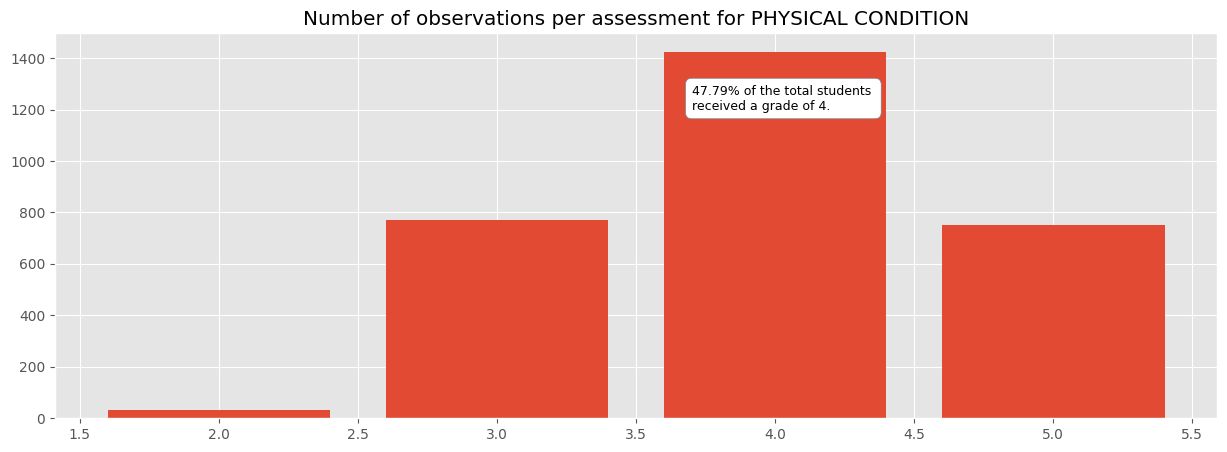

In [10]:
## What is the most common grading for PHYSICAL CONDITION?

viz_df = df.groupby("physical_condition")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["physical_condition"]
viz_df_y = viz_df["name_student"]

## Finding the proportion of students who received a grade of 4.0

four_rate = round((len(df[df["physical_condition"] == 4]) / len(df)) * 100, 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for PHYSICAL CONDITION")

## Annotating the chart

plt.text(
    3.7, 1200,
    f'{four_rate}% of the total students \nreceived a grade of 4.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)

## Showing the graph

plt.show()

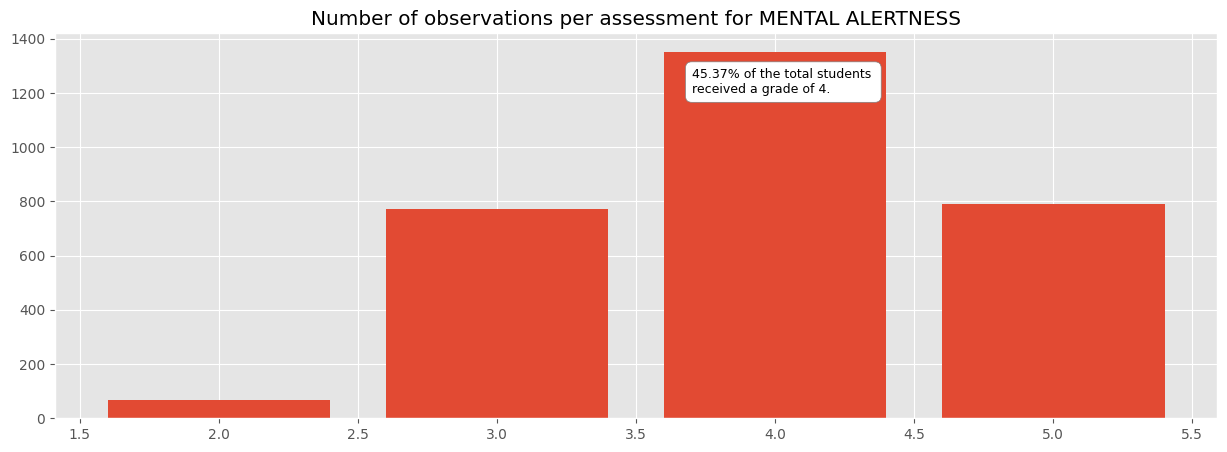

In [11]:
## What is the most common grading for MENTAL ALERTNESS?

viz_df = df.groupby("mental_alertness")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["mental_alertness"]
viz_df_y = viz_df["name_student"]

## Finding the proportion of students who received a grade of 4.0

four_rate = round((len(df[df["mental_alertness"] == 4]) / len(df)) * 100, 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for MENTAL ALERTNESS")

## Annotating the chart

plt.text(
    3.7, 1200,
    f'{four_rate}% of the total students \nreceived a grade of 4.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)


## Showing the graph

plt.show()

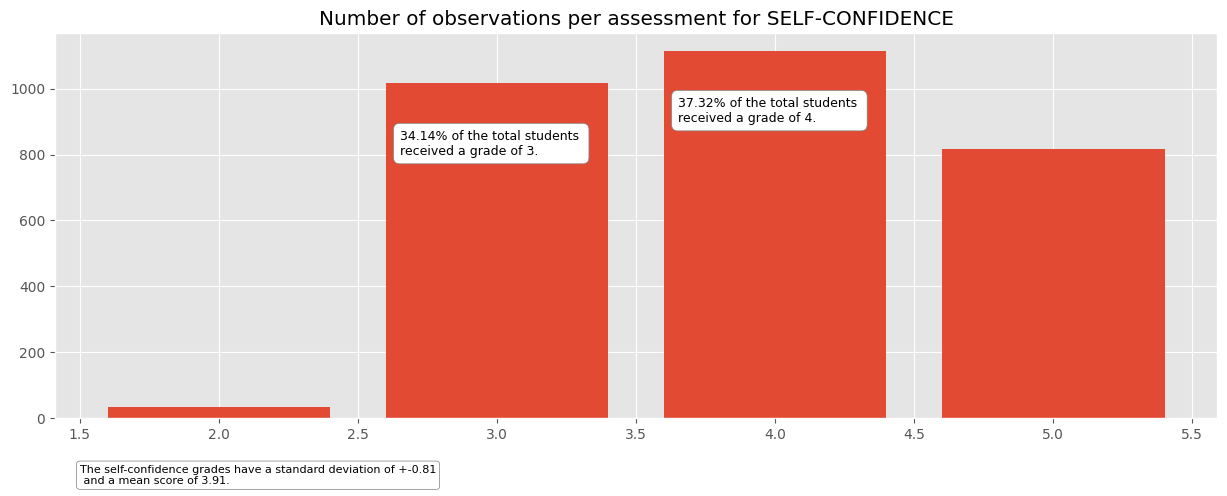

In [12]:
## What is the most common grading for SELF CONFIDENCE?

viz_df = df.groupby("self_confidence")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["self_confidence"]
viz_df_y = viz_df["name_student"]

## Finding the proportion of students who received a grade of 4.0

four_rate = round((len(df[df["self_confidence"] == 4]) / len(df)) * 100, 2)

three_rate = round((len(df[df["self_confidence"] == 3]) / len(df)) * 100, 2)

## Finding the variance 

df_mean = round(
    df["self_confidence"].mean(), 2)

df_variance = round(
    df["self_confidence"].var(ddof=0), 2)

df_std = round(
    df["self_confidence"].std(), 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for SELF-CONFIDENCE")

## Annotating the chart

plt.text(
    3.65, 900,
    f'{four_rate}% of the total students \nreceived a grade of 4.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)

plt.text(
    2.65, 800,
    f'{three_rate}% of the total students \nreceived a grade of 3.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)

## Annotating the variance
plt.text(
    1.5, -200,
    f'The self-confidence grades have a standard deviation of +-{df_std}\n and a mean score of {df_mean}.',
    fontsize=8,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.3"
    )
)


## Showing the graph

plt.show()

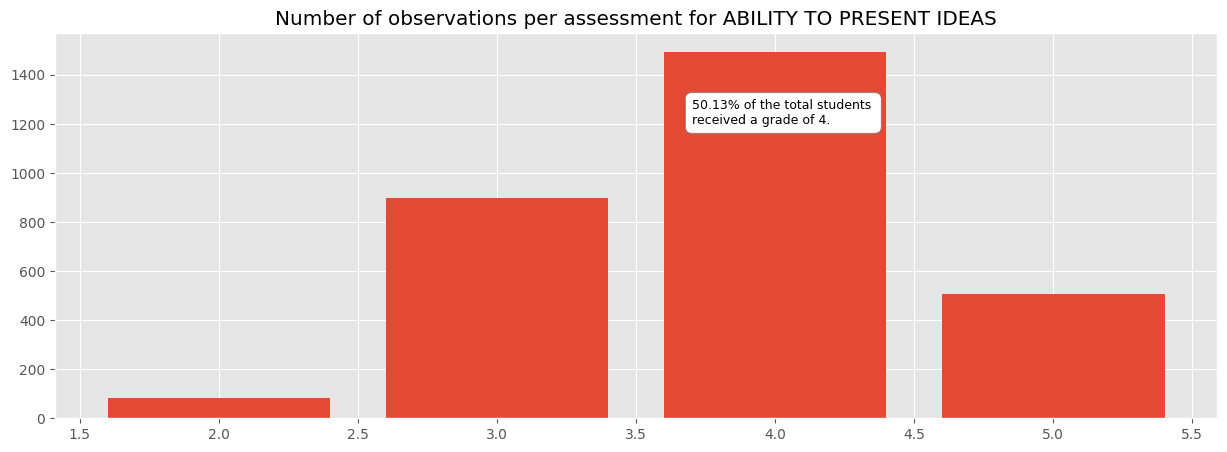

In [13]:
## What is the most common grading for ABILITY TO PRESENT IDEAS?

viz_df = df.groupby("ability_to_present_ideas")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["ability_to_present_ideas"]
viz_df_y = viz_df["name_student"]

## Finding the proportion of students who received a grade of 4.0

four_rate = round((len(df[df["ability_to_present_ideas"] == 4]) / len(df)) * 100, 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for ABILITY TO PRESENT IDEAS")

## Annotating the chart

plt.text(
    3.7, 1200,
    f'{four_rate}% of the total students \nreceived a grade of 4.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)


## Showing the graph

plt.show()

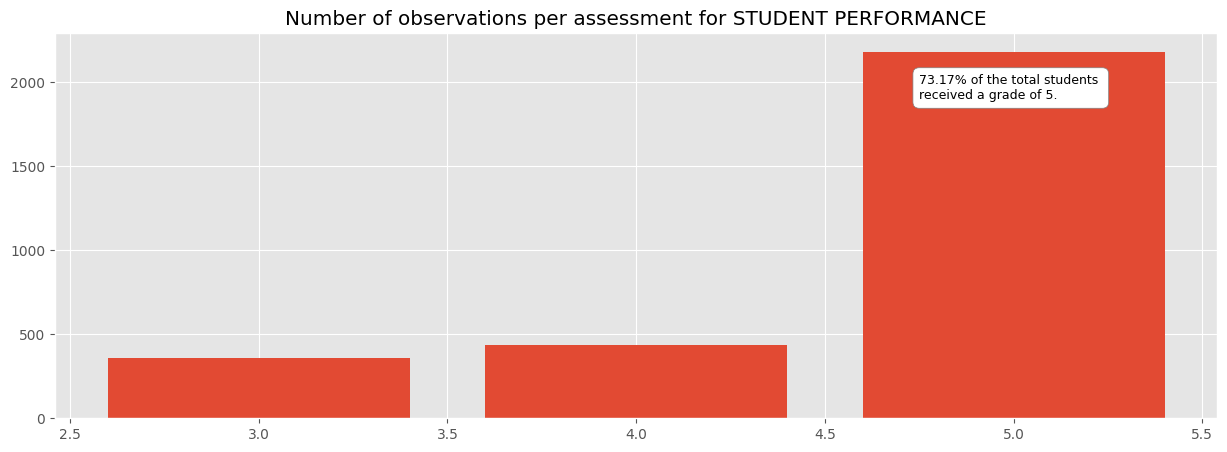

In [14]:
## What is the most common grading for STUDENT PERFORMANCE?

viz_df = df.groupby("student_performance")["name_student"].count()
viz_df = pd.DataFrame(viz_df).reset_index()

## Setting the axes

viz_df_x = viz_df["student_performance"]
viz_df_y = viz_df["name_student"]

## Finding the proportion of students who received a grade of 4.0

five_rate = round((len(df[df["student_performance"] == 5]) / len(df)) * 100, 2)

## creating the chart

plt.figure(figsize=(15,5))
plt.bar(viz_df_x, viz_df_y)
plt.title("Number of observations per assessment for STUDENT PERFORMANCE")

## Annotating the chart

plt.text(
    4.75, 1900,
    f'{five_rate}% of the total students \nreceived a grade of 5.',
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round, pad=0.5"
    ),
    fontsize=9
)


## Showing the graph

plt.show()

## LOGISTIC REGRESSION ##

In [15]:
## Converting the results into numeric

df["result_numeric"] = df["result"].map({"Employable":1,"LessEmployable":0})
df.head()

,name_student,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,comm_skills,student_performance,result,average_score,result_numeric
0,Student 1,4,5,4,5,5,5,5,5,Employable,4.750,1
1,Student 2,4,4,4,4,4,4,3,5,Employable,4.000,1
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable,3.250,0
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable,3.125,0
4,Student 5,4,4,3,3,4,4,3,5,Employable,3.750,1


In [16]:
## Preparing the dataframe by converting the results into numeric

df_feature = df[["general_appearance",
                 "manner_of_speaking",
                 "physical_condition",
                 "mental_alertness",
                "self_confidence",
                "ability_to_present_ideas",
                "comm_skills",
                "student_performance"]]

df_target = df["result_numeric"]

In [17]:
## Creating the test / train split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df_feature, df_target, test_size=0.2, random_state=42)

In [18]:
## Preparing the model for use

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(x_train, y_train)

LogisticRegression(max_iter=300)

In [19]:
## Use the model to predict the values for the test split

y_pred = model.predict(x_test)
y_pred

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,

In [20]:
## Evaluating the predictions' accuracy

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification = classification_report(y_test, y_pred)

print(f'''
ACCURACY SCORE: {accuracy}
CONFUSION MATRIX: {confusion}
CLASSIFICATION REPORT: {classification}''')


ACCURACY SCORE: 0.5946398659966499
CONFUSION MATRIX: [[ 95 170]
 [ 72 260]]
CLASSIFICATION REPORT:               precision    recall  f1-score   support

           0       0.57      0.36      0.44       265
           1       0.60      0.78      0.68       332

    accuracy                           0.59       597
   macro avg       0.59      0.57      0.56       597
weighted avg       0.59      0.59      0.57       597



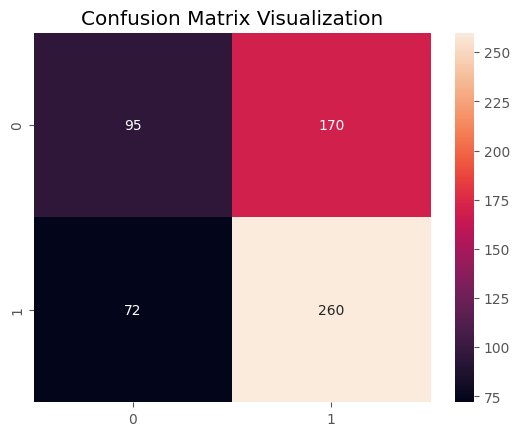

In [21]:
## Visualizing the confusion matrix

plt.title("Confusion Matrix Visualization")
sns.heatmap(confusion, annot=True, fmt="d")
plt.show()

A logistic regression on the tool shows an overoptimism in passing candidates - candidates pass more and more students ending up with false positives. 